# CNN Replica Notebook

This is the one to do .wav on

Goal: replicate the paper setup as closely as possible while using CSV amplitude vectors and a 1D CNN instead of FFT images and ResNet50.

Key similarities to the paper:
- Three-class supervised classification: Real, Fake High, Fake Low
- Paper-style six augmentation categories
- 90/10 train/test split
- 5-fold cross-validation
- Optimizer comparison: SGD, Adam, RMSProp
- Learning rate 0.001
- 100 epochs
- Mini-batch size 8

Key differences:
- CSV rows of 512 amplitude values instead of RGB FFT images
- Custom 1D CNN instead of pre-trained ResNet50


In [1]:
# ==============================
# Block 1: Data loading / preprocessing / augmentation
# ==============================

import os
import random
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# ------------------------------
# Reproducibility
# ------------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------
# Paths
# ------------------------------

RAW_DATA_DIR = Path("Kefra_Processed_Data")
AUG_DATA_DIR = Path("Kefra_Augmented_Data")
AUG_SCRIPT = Path("augment_kefra_csv.py")

USE_AUGMENTED_DATA = True
RUN_AUGMENTATION_SCRIPT = True

# This matches the paper's reported 6x augmentation factor.
# If include-original is set in the script, it becomes 7x instead.

if USE_AUGMENTED_DATA and RUN_AUGMENTATION_SCRIPT:
    if not AUG_SCRIPT.exists():
        raise FileNotFoundError(
            "augment_kefra_csv.py not found in the current directory. "
            "Place it next to this notebook or set AUG_SCRIPT correctly."
        )

    subprocess.run([
        "python", str(AUG_SCRIPT),
        "--input-dir", str(RAW_DATA_DIR),
        "--output-dir", str(AUG_DATA_DIR),
        "--seed", str(SEED)
    ], check=True)

DATA_DIR = AUG_DATA_DIR if USE_AUGMENTED_DATA else RAW_DATA_DIR

# ------------------------------
# Load CSV files
# ------------------------------

df_r = pd.read_csv(DATA_DIR / "Real.csv")
df_fh = pd.read_csv(DATA_DIR / "Fake_High.csv")
df_fl = pd.read_csv(DATA_DIR / "Fake_Low.csv")

print("Real:", df_r.shape)
print("Fake High:", df_fh.shape)
print("Fake Low:", df_fl.shape)

# Keep file names for traceability, but train only on numeric columns.
files_r = df_r["file"].copy() if "file" in df_r.columns else pd.Series([f"real_{i}" for i in range(len(df_r))])
files_fh = df_fh["file"].copy() if "file" in df_fh.columns else pd.Series([f"fake_high_{i}" for i in range(len(df_fh))])
files_fl = df_fl["file"].copy() if "file" in df_fl.columns else pd.Series([f"fake_low_{i}" for i in range(len(df_fl))])

X_real = df_r.drop(columns=["file"], errors="ignore").to_numpy(dtype=np.float32)
X_fh = df_fh.drop(columns=["file"], errors="ignore").to_numpy(dtype=np.float32)
X_fl = df_fl.drop(columns=["file"], errors="ignore").to_numpy(dtype=np.float32)

assert X_real.shape[1] == 512, f"Expected 512 columns, got {X_real.shape[1]}"
assert X_fh.shape[1] == 512, f"Expected 512 columns, got {X_fh.shape[1]}"
assert X_fl.shape[1] == 512, f"Expected 512 columns, got {X_fl.shape[1]}"

# Labels: 0=Real, 1=Fake High, 2=Fake Low
X = np.vstack([X_real, X_fh, X_fl]).astype(np.float32)
y = np.concatenate([
    np.zeros(len(X_real), dtype=np.int64),
    np.ones(len(X_fh), dtype=np.int64),
    np.full(len(X_fl), 2, dtype=np.int64)
])
files = pd.concat([files_r, files_fh, files_fl], ignore_index=True)

class_names = ["Real", "Fake High", "Fake Low"]

# Fully shuffle before the 90/10 split, while preserving X/y/file alignment.
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(X))
X = X[perm]
y = y[perm]
files = files.iloc[perm].reset_index(drop=True)

print("Combined X:", X.shape)
print("Combined class counts:", pd.Series(y).value_counts().sort_index().to_dict())


Kefra_Processed_Data/Real.csv -> Kefra_Augmented_Data/Real.csv: 110 rows -> 660 rows
Kefra_Processed_Data/Fake_High.csv -> Kefra_Augmented_Data/Fake_High.csv: 110 rows -> 660 rows
Kefra_Processed_Data/Fake_Low.csv -> Kefra_Augmented_Data/Fake_Low.csv: 120 rows -> 720 rows
Done. Augmented CSVs are in: Kefra_Augmented_Data
Real: (660, 513)
Fake High: (660, 513)
Fake Low: (720, 513)
Combined X: (2040, 512)
Combined class counts: {0: 660, 1: 660, 2: 720}


In [2]:
# ==============================
# Block 2: 1D CNN model, training, testing functions
# ==============================

import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BATCH_SIZE = 8          # same as paper
LEARNING_RATE = 1e-3    # same as paper
NUM_EPOCHS = 100        # same as paper


def make_activation(name: str):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "leakyrelu":
        return nn.LeakyReLU(negative_slope=0.01)
    if name == "elu":
        return nn.ELU()
    raise ValueError(f"Unknown activation: {name}")


class CNN1DClassifier(nn.Module):
    """Small 1D CNN classifier for 512-point amplitude vectors."""

    def __init__(self, num_classes=3, activation="relu"):
        super().__init__()
        act1 = make_activation(activation)
        act2 = make_activation(activation)
        act3 = make_activation(activation)
        act4 = make_activation(activation)

        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3),   # 512 -> 256
            act1,
            nn.BatchNorm1d(16),

            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),  # 256 -> 128
            act2,
            nn.BatchNorm1d(32),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),  # 128 -> 64
            act3,
            nn.BatchNorm1d(64),

            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1), # 64 -> 32
            act4,
            nn.BatchNorm1d(128),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            make_activation(activation),
            nn.Dropout(0.20),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def make_optimizer(name: str, model: nn.Module, lr: float):
    name = name.lower()
    if name == "sgd":
        return optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    if name == "adam":
        return optim.Adam(model.parameters(), lr=lr)
    if name == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=lr, momentum=0.9)
    raise ValueError(f"Unknown optimizer: {name}")


def scale_and_tensorize(X_train, X_test):
    # Fit scaler on training only to avoid leakage.
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train).astype(np.float32)
    X_test_s = scaler.transform(X_test).astype(np.float32)

    # Conv1d expects [batch, channels, length].
    X_train_t = torch.tensor(X_train_s).unsqueeze(1)
    X_test_t = torch.tensor(X_test_s).unsqueeze(1)
    return X_train_t, X_test_t, scaler


def make_loader(X_tensor, y_array, batch_size=BATCH_SIZE, shuffle=False):
    y_tensor = torch.tensor(y_array, dtype=torch.long)
    return DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)


def train_model(X_train, y_train, X_test, y_test, optimizer_name="sgd", activation="relu", verbose=False):
    X_train_t, X_test_t, scaler = scale_and_tensorize(X_train, X_test)
    train_loader = make_loader(X_train_t, y_train, shuffle=True)
    test_loader = make_loader(X_test_t, y_test, shuffle=False)

    model = CNN1DClassifier(num_classes=3, activation=activation).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(optimizer_name, model, LEARNING_RATE)

    train_losses = []

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(f"Epoch {epoch+1:03d}/{NUM_EPOCHS} | loss={epoch_loss:.6f}")

    y_pred, y_prob = predict_model(model, test_loader)

    return {
        "model": model,
        "scaler": scaler,
        "train_losses": train_losses,
        "y_pred": y_pred,
        "y_prob": y_prob,
    }


def predict_model(model, loader):
    model.eval()
    preds = []
    probs = []

    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            logits = model(xb)
            p = torch.softmax(logits, dim=1)
            pred = torch.argmax(p, dim=1)
            preds.extend(pred.cpu().numpy())
            probs.extend(p.cpu().numpy())

    return np.array(preds), np.array(probs)


def summarize_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }


Using device: cuda


In [3]:
# ==============================
# Block 3: 90/10 test split experiments, matching the paper structure
# ==============================

# Paper-like split: 90% train, 10% test, stratified by class.
X_train, X_test, y_train, y_test, files_train, files_test = train_test_split(
    X, y, files,
    test_size=0.10,
    random_state=SEED,
    shuffle=True,
    stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train counts:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("Test counts:", pd.Series(y_test).value_counts().sort_index().to_dict())

optimizers_to_test = ["sgd", "adam", "rmsprop"]
activations_to_test = ["relu", "leakyrelu", "elu"]

results_90_10 = []
trained_runs = {}

for opt_name in optimizers_to_test:
    for act_name in activations_to_test:
        print(f"\nTraining 90/10 model: optimizer={opt_name}, activation={act_name}")
        run = train_model(
            X_train, y_train, X_test, y_test,
            optimizer_name=opt_name,
            activation=act_name,
            verbose=False
        )
        y_pred = run["y_pred"]
        metrics = summarize_metrics(y_test, y_pred)
        metrics.update({"optimizer": opt_name, "activation": act_name})
        results_90_10.append(metrics)
        trained_runs[(opt_name, act_name)] = run
        print(metrics)

results_90_10_df = pd.DataFrame(results_90_10).sort_values(
    by=["accuracy", "macro_f1"], ascending=False
).reset_index(drop=True)

results_90_10_df


Train shape: (1836, 512) Test shape: (204, 512)
Train counts: {0: 594, 1: 594, 2: 648}
Test counts: {0: 66, 1: 66, 2: 72}

Training 90/10 model: optimizer=sgd, activation=relu
{'accuracy': 0.8627450980392157, 'macro_precision': 0.869185342740541, 'macro_recall': 0.8627946127946128, 'macro_f1': 0.8648875589481525, 'optimizer': 'sgd', 'activation': 'relu'}

Training 90/10 model: optimizer=sgd, activation=leakyrelu
{'accuracy': 0.8382352941176471, 'macro_precision': 0.8400038238480659, 'macro_recall': 0.8396464646464646, 'macro_f1': 0.8397344936025578, 'optimizer': 'sgd', 'activation': 'leakyrelu'}

Training 90/10 model: optimizer=sgd, activation=elu
{'accuracy': 0.7647058823529411, 'macro_precision': 0.7639764513003949, 'macro_recall': 0.7676767676767677, 'macro_f1': 0.7654238905948892, 'optimizer': 'sgd', 'activation': 'elu'}

Training 90/10 model: optimizer=adam, activation=relu
{'accuracy': 0.8431372549019608, 'macro_precision': 0.8429919584588154, 'macro_recall': 0.8472222222222223, 

,accuracy,macro_precision,macro_recall,macro_f1,optimizer,activation
0,0.862745,0.869185,0.862795,0.864888,sgd,relu
1,0.862745,0.864966,0.864899,0.864322,rmsprop,elu
2,0.857843,0.859643,0.858586,0.858508,adam,leakyrelu
3,0.843137,0.842992,0.847222,0.842235,adam,relu
4,0.838235,0.840004,0.839646,0.839734,sgd,leakyrelu
5,0.823529,0.829095,0.824495,0.826292,adam,elu
6,0.823529,0.826339,0.826178,0.825900,rmsprop,relu
7,0.794118,0.811585,0.793771,0.799328,rmsprop,leakyrelu
8,0.764706,0.763976,0.767677,0.765424,sgd,elu


Class names: ['Real', 'Fake High', 'Fake Low']
Paper-style performance indicators for all saved 90/10 models:


,optimizer,activation,NCC,NIC,ACC,PRC_weighted,RCL_weighted,F1S_weighted,PRC_macro,RCL_macro,F1S_macro,INF_total_sec,INF_per_sample_sec
0,sgd,relu,176,28,0.862745,0.866704,0.862745,0.863602,0.869185,0.862795,0.864888,0.012628,0.000062
1,rmsprop,elu,176,28,0.862745,0.864180,0.862745,0.862851,0.864966,0.864899,0.864322,0.010816,0.000053
2,adam,leakyrelu,175,29,0.857843,0.857889,0.857843,0.857267,0.859643,0.858586,0.858508,0.012204,0.000060
3,adam,relu,172,32,0.843137,0.842788,0.843137,0.840020,0.842992,0.847222,0.842235,0.011779,0.000058
4,sgd,leakyrelu,171,33,0.838235,0.838910,0.838235,0.838484,0.840004,0.839646,0.839734,0.012309,0.000060
5,adam,elu,168,36,0.823529,0.826482,0.823529,0.824492,0.829095,0.824495,0.826292,0.015496,0.000076
6,rmsprop,relu,168,36,0.823529,0.824304,0.823529,0.823564,0.826339,0.826178,0.825900,0.011389,0.000056
7,rmsprop,leakyrelu,162,42,0.794118,0.807784,0.794118,0.797550,0.811585,0.793771,0.799328,0.011949,0.000059
8,sgd,elu,156,48,0.764706,0.761391,0.764706,0.762656,0.763976,0.767677,0.765424,0.014330,0.000070



Best model:
optimizer                  sgd
activation                relu
NCC                        176
NIC                         28
ACC                   0.862745
PRC_weighted          0.866704
RCL_weighted          0.862745
F1S_weighted          0.863602
PRC_macro             0.869185
RCL_macro             0.862795
F1S_macro             0.864888
INF_total_sec         0.012628
INF_per_sample_sec    0.000062
Name: 0, dtype: object

Confusion matrix for best model:


,Predicted_Real,Predicted_Fake High,Predicted_Fake Low
Actual_Real,60,0,6
Actual_Fake High,1,54,11
Actual_Fake Low,3,7,62



Correlation matrix of numerical model metrics:


,NCC,NIC,ACC,PRC_weighted,RCL_weighted,F1S_weighted,PRC_macro,RCL_macro,F1S_macro,INF_total_sec,INF_per_sample_sec
NCC,1.000000,-1.000000,1.000000,0.989644,1.000000,0.998421,0.986070,0.999050,0.998770,-0.466491,-0.466491
NIC,-1.000000,1.000000,-1.000000,-0.989644,-1.000000,-0.998421,-0.986070,-0.999050,-0.998770,0.466491,0.466491
ACC,1.000000,-1.000000,1.000000,0.989644,1.000000,0.998421,0.986070,0.999050,0.998770,-0.466491,-0.466491
PRC_weighted,0.989644,-0.989644,0.989644,1.000000,0.989644,0.995080,0.999563,0.984135,0.994648,-0.489377,-0.489377
RCL_weighted,1.000000,-1.000000,1.000000,0.989644,1.000000,0.998421,0.986070,0.999050,0.998770,-0.466491,-0.466491
F1S_weighted,0.998421,-0.998421,0.998421,0.995080,0.998421,1.000000,0.992900,0.995331,0.999944,-0.468024,-0.468024
PRC_macro,0.986070,-0.986070,0.986070,0.999563,0.986070,0.992900,1.000000,0.979389,0.992295,-0.482797,-0.482797
RCL_macro,0.999050,-0.999050,0.999050,0.984135,0.999050,0.995331,0.979389,1.000000,0.996066,-0.474076,-0.474076
F1S_macro,0.998770,-0.998770,0.998770,0.994648,0.998770,0.999944,0.992295,0.996066,1.000000,-0.469755,-0.469755
INF_total_sec,-0.466491,0.466491,-0.466491,-0.489377,-0.466491,-0.468024,-0.482797,-0.474076,-0.469755,1.000000,1.000000


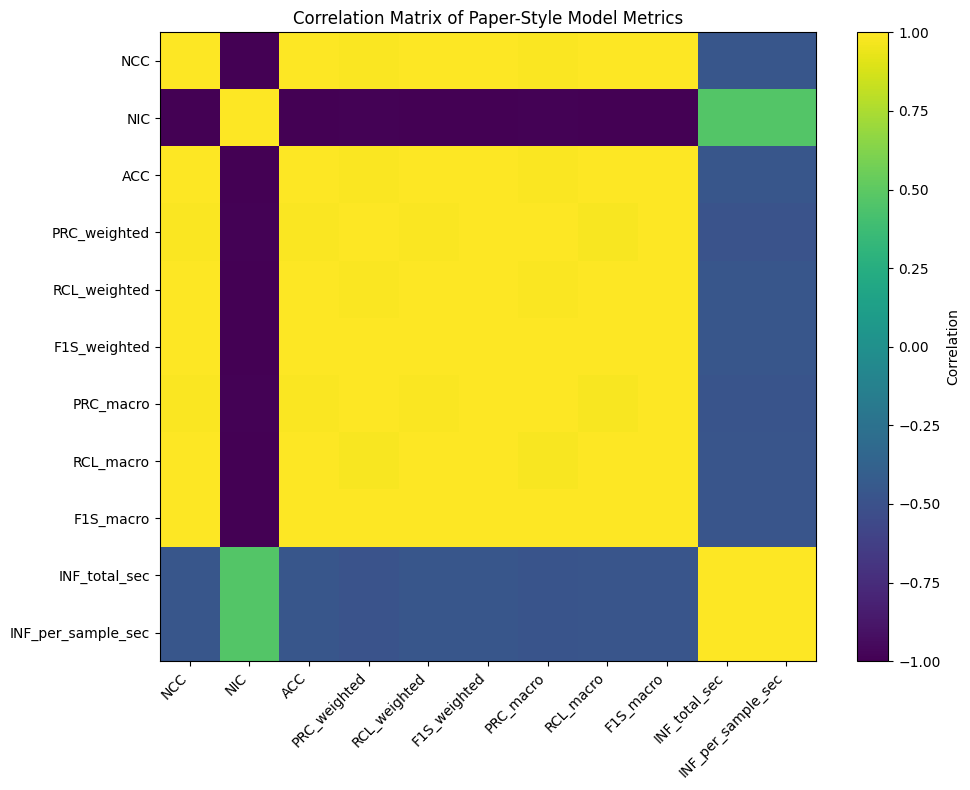

In [4]:
# ============================================================
# Paper-style metrics for all saved 90/10 trained models
# Includes NCC, NIC, ACC, PRC, RCL, F1S, INF + correlation matrix
# ============================================================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Make sure class order matches your notebook labels
# In your notebook, class_names should already exist.
print("Class names:", class_names)

paper_metric_rows = []
confusion_matrices = {}

for (opt_name, act_name), run in trained_runs.items():
    model = run["model"]
    scaler = run["scaler"]

    # Scale test set using the scaler saved for this exact trained model
    X_test_s = scaler.transform(X_test).astype(np.float32)
    X_test_t = torch.tensor(X_test_s).unsqueeze(1)

    test_loader_for_timing = make_loader(
        X_test_t,
        y_test,
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    # Measure inference time
    start = time.perf_counter()
    y_pred, y_prob = predict_model(model, test_loader_for_timing)
    end = time.perf_counter()

    inf_total_sec = end - start
    inf_per_sample_sec = inf_total_sec / len(y_test)

    cm = confusion_matrix(y_test, y_pred)

    NCC = int(np.trace(cm))
    NIC = int(np.sum(cm) - NCC)

    ACC = accuracy_score(y_test, y_pred)

    # Paper says "overall"; weighted is usually the safest overall metric.
    PRC_weighted = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    RCL_weighted = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    F1S_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    # Macro treats each class equally.
    PRC_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    RCL_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    F1S_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

    row = {
        "optimizer": opt_name,
        "activation": act_name,
        "NCC": NCC,
        "NIC": NIC,
        "ACC": ACC,
        "PRC_weighted": PRC_weighted,
        "RCL_weighted": RCL_weighted,
        "F1S_weighted": F1S_weighted,
        "PRC_macro": PRC_macro,
        "RCL_macro": RCL_macro,
        "F1S_macro": F1S_macro,
        "INF_total_sec": inf_total_sec,
        "INF_per_sample_sec": inf_per_sample_sec
    }

    paper_metric_rows.append(row)
    confusion_matrices[(opt_name, act_name)] = cm

paper_metrics_df = pd.DataFrame(paper_metric_rows)

paper_metrics_df = paper_metrics_df.sort_values(
    by=["ACC", "F1S_weighted"],
    ascending=False
).reset_index(drop=True)

print("Paper-style performance indicators for all saved 90/10 models:")
display(paper_metrics_df)

# Save summary table
paper_metrics_df.to_csv("paper_style_metrics_all_90_10_models.csv", index=False)

# ============================================================
# Show confusion matrix for the best model
# ============================================================

best_row = paper_metrics_df.iloc[0]
best_key = (best_row["optimizer"], best_row["activation"])
best_cm = confusion_matrices[best_key]

print("\nBest model:")
print(best_row)

print("\nConfusion matrix for best model:")
best_cm_df = pd.DataFrame(
    best_cm,
    index=[f"Actual_{c}" for c in class_names],
    columns=[f"Predicted_{c}" for c in class_names]
)
display(best_cm_df)

best_cm_df.to_csv("best_model_confusion_matrix.csv")

# ============================================================
# Correlation matrix across model-level numerical metrics
# ============================================================

corr_input = paper_metrics_df.drop(columns=["optimizer", "activation"])

corr_df = corr_input.corr(numeric_only=True)

print("\nCorrelation matrix of numerical model metrics:")
display(corr_df)

corr_df.to_csv("paper_style_metrics_correlation_matrix.csv")

plt.figure(figsize=(10, 8))
plt.imshow(corr_df, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.title("Correlation Matrix of Paper-Style Model Metrics")
plt.tight_layout()
plt.show()

In [5]:
# Detailed report for the best 90/10 model

best = results_90_10_df.iloc[0]
best_key = (best["optimizer"], best["activation"])
best_run = trained_runs[best_key]

print("Best 90/10 configuration:")
print(best)

print("\nClassification report:")
print(classification_report(y_test, best_run["y_pred"], target_names=class_names, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(y_test, best_run["y_pred"]))


Best 90/10 configuration:
accuracy           0.862745
macro_precision    0.869185
macro_recall       0.862795
macro_f1           0.864888
optimizer               sgd
activation             relu
Name: 0, dtype: object

Classification report:
              precision    recall  f1-score   support

        Real       0.94      0.91      0.92        66
   Fake High       0.89      0.82      0.85        66
    Fake Low       0.78      0.86      0.82        72

    accuracy                           0.86       204
   macro avg       0.87      0.86      0.86       204
weighted avg       0.87      0.86      0.86       204

Confusion matrix:
[[60  0  6]
 [ 1 54 11]
 [ 3  7 62]]


In [ ]:
# ==============================
# Block 4: 5-fold cross-validation
# ==============================

# This mirrors the paper's 5-fold CV idea, but uses the 1D CNN and CSV data.
# Each fold refits the scaler only on the training fold to avoid leakage.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = []

for opt_name in optimizers_to_test:
    for act_name in activations_to_test:
        print(f"\n5-fold CV: optimizer={opt_name}, activation={act_name}")

        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
            X_tr, X_te = X[train_idx], X[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]

            run = train_model(
                X_tr, y_tr, X_te, y_te,
                optimizer_name=opt_name,
                activation=act_name,
                verbose=False
            )

            metrics = summarize_metrics(y_te, run["y_pred"])
            metrics.update({
                "optimizer": opt_name,
                "activation": act_name,
                "fold": fold,
            })
            cv_results.append(metrics)
            print(f"  fold={fold} acc={metrics['accuracy']:.4f} f1={metrics['macro_f1']:.4f}")

cv_results_df = pd.DataFrame(cv_results)

cv_summary_df = (
    cv_results_df
    .groupby(["optimizer", "activation"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        macro_precision_mean=("macro_precision", "mean"),
        macro_recall_mean=("macro_recall", "mean"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
    )
    .reset_index()
    .sort_values(by=["accuracy_mean", "macro_f1_mean"], ascending=False)
)

cv_summary_df



5-fold CV: optimizer=sgd, activation=relu
  fold=1 acc=0.8260 f1=0.8277
  fold=2 acc=0.7819 f1=0.7826
  fold=3 acc=0.8186 f1=0.8209


In [ ]:
# Save results for reporting

results_90_10_df.to_csv("cnn_replica_90_10_results.csv", index=False)
cv_results_df.to_csv("cnn_replica_5fold_raw_results.csv", index=False)
cv_summary_df.to_csv("cnn_replica_5fold_summary.csv", index=False)

print("Saved:")
print("- cnn_replica_90_10_results.csv")
print("- cnn_replica_5fold_raw_results.csv")
print("- cnn_replica_5fold_summary.csv")
